# Design of Experiment: Optimize perovskite solar cells efficiency

This notebook is made to use optimPV for experimental design. Here, we show how to load some data from a presampling, and how to use optimPV to suggest the next set of experiment using Bayesian optimization.
The goal here is to optimize the processing conditions for a perovskite solar cell to maximize the power conversion efficiency (PCE).

Note: The data used here is real data generated in the [i-MEET](https://www.i-meet.ww.uni-erlangen.de/) and [HI-ERN](https://www.hi-ern.de/de) labs at the university of Erlangen-Nuremberg (FAU) by Jiyun Zhang for the paper: [Autonomous Optimization of Air-Processed Perovskite Solar Cell in a 6D Parameter Space](https://doi.org/10.1002/aenm.202404957)


In [1]:
# Import necessary libraries
import warnings, os, sys
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer

## Get the data

In [2]:
# Define the path to the data 
data_dir =os.path.join(os.path.abspath('../'),'Data','6D_pero_opti') # path to the data directory

# Load the data
df = pd.read_csv(os.path.join(data_dir,'6D_pero_opti.csv'),sep=r'\s+') # load the data

# Display some information about the data
print(df.describe())

       Spin_Speed_1  Duration_t1  Spin_Speed_2  Dispense_Speed  Duration_t3  \
count     76.000000    76.000000     76.000000       76.000000    76.000000   
mean    1520.486842    18.276316   2273.289474      234.697368    17.315789   
std      458.510240     7.000188    501.488845       83.133470     7.919950   
min      540.000000     5.000000   1021.000000       16.000000     5.000000   
25%     1203.500000    13.750000   2019.500000      201.750000    10.750000   
50%     1511.000000    18.000000   2385.500000      247.500000    17.000000   
75%     1801.250000    22.000000   2671.000000      277.500000    23.250000   
max     2579.000000    34.000000   3000.000000      396.000000    35.000000   

       Spin_Speed_3        Jsc        Voc         FF       Pmax       Vmpp  \
count     76.000000  76.000000  76.000000  76.000000  76.000000  76.000000   
mean    3717.789474  24.391395   1.021157   0.724692  18.320711   0.825778   
std      917.207346   1.872929   0.108197   0.055290  

## Define the parameters for the simulation

In [3]:
params = [] # list of parameters to be optimized

Spin_Speed_1 = FitParam(name = 'Spin_Speed_1', value = 1000, bounds = [500,3000], value_type = 'float', display_name='Spin Speed 1', unit='rpm', axis_type = 'linear')
params.append(Spin_Speed_1)

Duration_t1 = FitParam(name = 'Duration_t1', value = 10, bounds = [5,35], value_type = 'float', display_name='Duration t1', unit='s', axis_type = 'linear')
params.append(Duration_t1)

Spin_Speed_2 = FitParam(name = 'Spin_Speed_2', value = 1000, bounds = [1000,3000], value_type = 'float', display_name='Spin Speed 2', unit='rpm', axis_type = 'linear')
params.append(Spin_Speed_2)

Dispense_Speed = FitParam(name = 'Dispense_Speed', value = 100, bounds = [10,400], value_type = 'float', display_name='Dispense Speed', unit='rpm', axis_type = 'linear')
params.append(Dispense_Speed)

Duration_t3 = FitParam(name = 'Duration_t3', value = 10, bounds = [5,35], value_type = 'float', display_name='Duration t3', unit='s', axis_type = 'linear')
params.append(Duration_t3)

Spin_Speed_3 = FitParam(name = 'Spin_Speed_3', value = 3000, bounds = [2000,5000], value_type = 'float', display_name='Spin Speed 3', unit='rpm', axis_type = 'linear')
params.append(Spin_Speed_3)


## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.general.SuggestOnlyAgent import SuggestOnlyAgent

suggest = SuggestOnlyAgent(params,exp_format='Pmax',minimize=False,tracking_exp_format=['Jsc','Voc','FF'],name=None)


In [5]:
# Define the optimizer
optimizer = PymooOptimizer(params=params, agents=suggest, algorithm='GA', pop_size=6, n_gen=1, name='pymoo_single_obj', verbose_logging=True,max_parallelism=20,existing_data=df, suggest_only=True)

In [6]:
to_run_next = optimizer.optimize() # run the optimization with pymoo
print(to_run_next)

[INFO 01-20 10:27:00] optimpv.pymooOptimizer: Starting optimization using GA algorithm
[INFO 01-20 10:27:00] optimpv.pymooOptimizer: Population size: 6, Generations: 1
[INFO 01-20 10:27:00] optimpv.pymooOptimizer: Using existing population of size 76
[INFO 01-20 10:27:00] optimpv.pymooOptimizer: Suggesting new points without running agents


   Spin_Speed_1  Duration_t1  Spin_Speed_2  Dispense_Speed  Duration_t3  \
0    929.036995    23.005446   1660.352671      315.159857    27.500998   
1   1871.615281    33.228110   2551.424113      121.113338    12.396043   
2    520.577993     7.366979   2328.103550      363.854725    15.677440   
3   2618.113920    24.337281   1242.700817      259.025808    34.783995   
4    792.886919    13.789641   2919.778841       15.241482    22.072239   
5   1739.231126    22.126389   1509.542469      311.397956    29.195343   

   Spin_Speed_3  
0   2953.961855  
1   4177.230204  
2   3791.927302  
3   3771.771594  
4   2917.544700  
5   2771.506583  


In [7]:
# get the best parameters and update the params list in the optimizer and the agent
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
suggest.params = optimizer.params # update the params list in the agent with the best parameters

print("Best parameters found:")
for p in optimizer.params:
    print(f"{p.name}: {p.value} {p.unit} ")

Best parameters found:
Spin_Speed_1: 1165 rpm 
Duration_t1: 23 s 
Spin_Speed_2: 2063 rpm 
Dispense_Speed: 241 rpm 
Duration_t3: 32 s 
Spin_Speed_3: 2863 rpm 


Best value seen so far is  23.729 at iteration  27


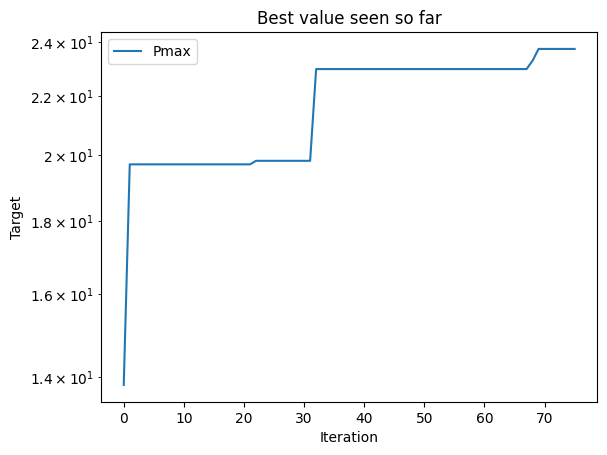

In [8]:
# Plot optimization results
data = optimizer.get_df_from_pymoo()
all_metrics = optimizer.all_metrics
all_minimize = optimizer.all_minimize

plt.figure()
for i, metric in enumerate(all_metrics):
    if all_minimize[i]:
        plt.plot(np.minimum.accumulate(data[metric]), label=metric, )
    else:
        plt.plot(np.maximum.accumulate(data[metric]), label=metric, )

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target")
plt.legend()
plt.title("Best value seen so far")

print("Best value seen so far is ", max(data[all_metrics[0]]), "at iteration ", int(data[all_metrics[0]].idxmin()))

plt.show()

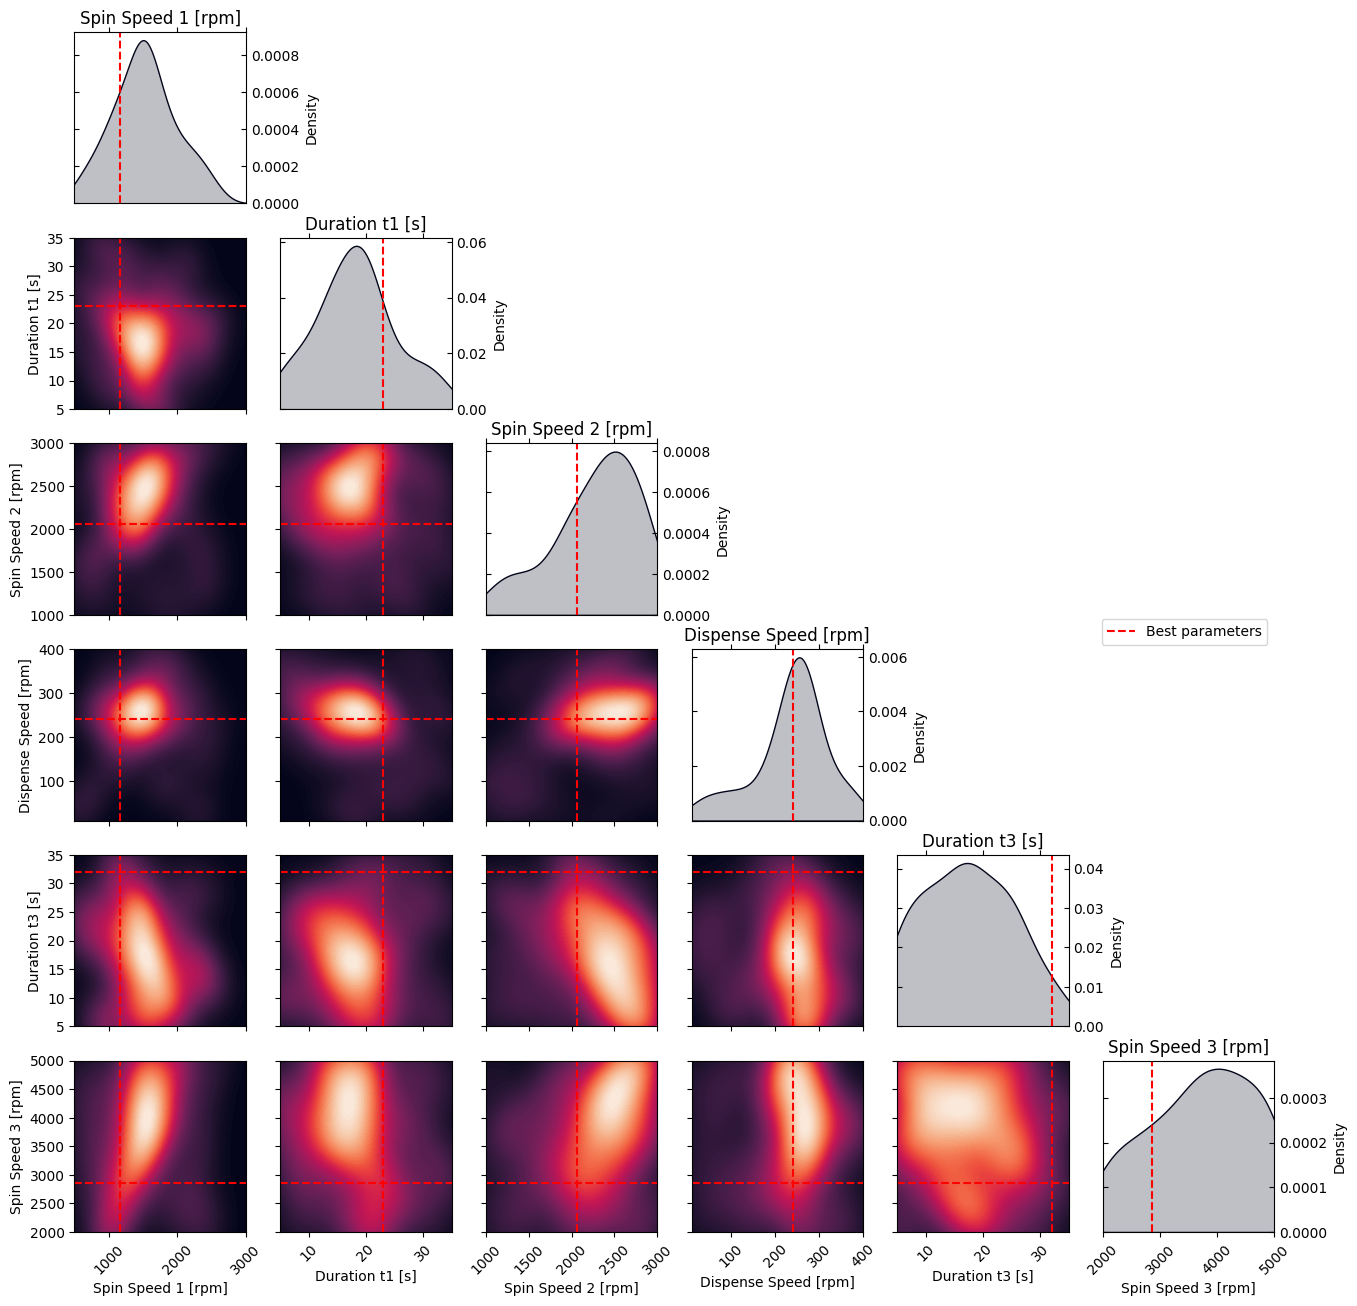

In [9]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    params_orig_dict, best_parameters = {}, {}
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters,  optimizer_type = 'pymoo')
